# PCAiv - rhone dataset

In [1]:
#disable warnings
from warnings import simplefilter, filterwarnings
simplefilter(action='ignore', category=FutureWarning)
filterwarnings("ignore")

## rhone dataset

In [2]:
# rhone dataset
from scientisttools.datasets import rhone
rhone._fields

('actif', 'sup_var', 'data')

In [3]:
# overall dataset
data = rhone.data
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   air.temp    39 non-null     int64  
 1   wat.temp    39 non-null     float64
 2   conduc      39 non-null     int64  
 3   pH          39 non-null     float64
 4   oxygen      39 non-null     int64  
 5   secchi      39 non-null     int64  
 6   caco3       39 non-null     int64  
 7   totca       39 non-null     float64
 8   mg          39 non-null     float64
 9   so4         39 non-null     float64
 10  no2         39 non-null     float64
 11  hco3        39 non-null     float64
 12  suspension  39 non-null     float64
 13  organique   39 non-null     float64
 14  chloro      39 non-null     float64
 15  Geneva      39 non-null     float64
 16  Arve        39 non-null     float64
 17  Others      39 non-null     float64
dtypes: float64(13), int64(5)
memory usage: 5.6 KB


## Instanciation and training

In [4]:
from scientisttools import PCA
#instanciation
clf = PCA(iv=(15,16,17))

## `fit` function

In [5]:
# fit
clf.fit(data)

,iv,"(15, ...)"
,scale_unit,True
,ortho,False
,partial,None
,group,None
,option,'between'
,ncp,5
,row_w,None
,col_w,None
,ind_sup,None
,sup_var,None


## `fit_transform` function

In [6]:
#fit_transform - individuals coordinates
ind_coord = clf.fit_transform(data)
ind_coord

,Dim1,Dim2,Dim3
0,0.774782,-0.008606,-0.599332
1,1.075483,-1.134220,-0.315285
2,2.532352,0.660453,-0.122311
3,-0.533954,0.267069,-0.664771
4,0.018490,2.148687,-0.642955
5,-1.590846,5.273165,0.295025
6,0.312522,5.830196,-1.735128
7,-1.041387,1.136616,-1.189703
8,-1.401550,-0.043288,-0.516144
9,-2.241797,0.151305,0.637322


### `transform` function

In [7]:
# transform - individuals coordinates
ind_coord = clf.transform(data)
ind_coord

,Dim1,Dim2,Dim3
0,0.774782,-0.008606,-0.599332
1,1.075483,-1.134220,-0.315285
2,2.532352,0.660453,-0.122311
3,-0.533954,0.267069,-0.664771
4,0.018490,2.148687,-0.642955
5,-1.590846,5.273165,0.295025
6,0.312522,5.830196,-1.735128
7,-1.041387,1.136616,-1.189703
8,-1.401550,-0.043288,-0.516144
9,-2.241797,0.151305,0.637322


In [8]:
# attributes
from scientisttools import sprintf
sprintf(clf)


**Results of the Principal Component Analysis (PCA)**

*The results are available in the following objects:

name          description
------------  -----------------------------------------------------
.call_        summary called parameters
.eig_         eigenvalues
.ind_         results for the individuals
.iv_          results for the instrumental variables
.quanti_var_  results for the quantitative variables
.svd_         results for generalized singular values decomposition



## Eigen values

In [9]:
#PCA eigen values
from scientisttools import get_eig
eig = get_eig(clf)
eig

,Eigenvalue,Difference,Proportion (%),Cumulative (%)
Dim1,3.703109,0.165012,49.095090,49.095090
Dim2,3.538097,3.236575,46.907390,96.002481
Dim3,0.301522,NaN,3.997519,100.000000


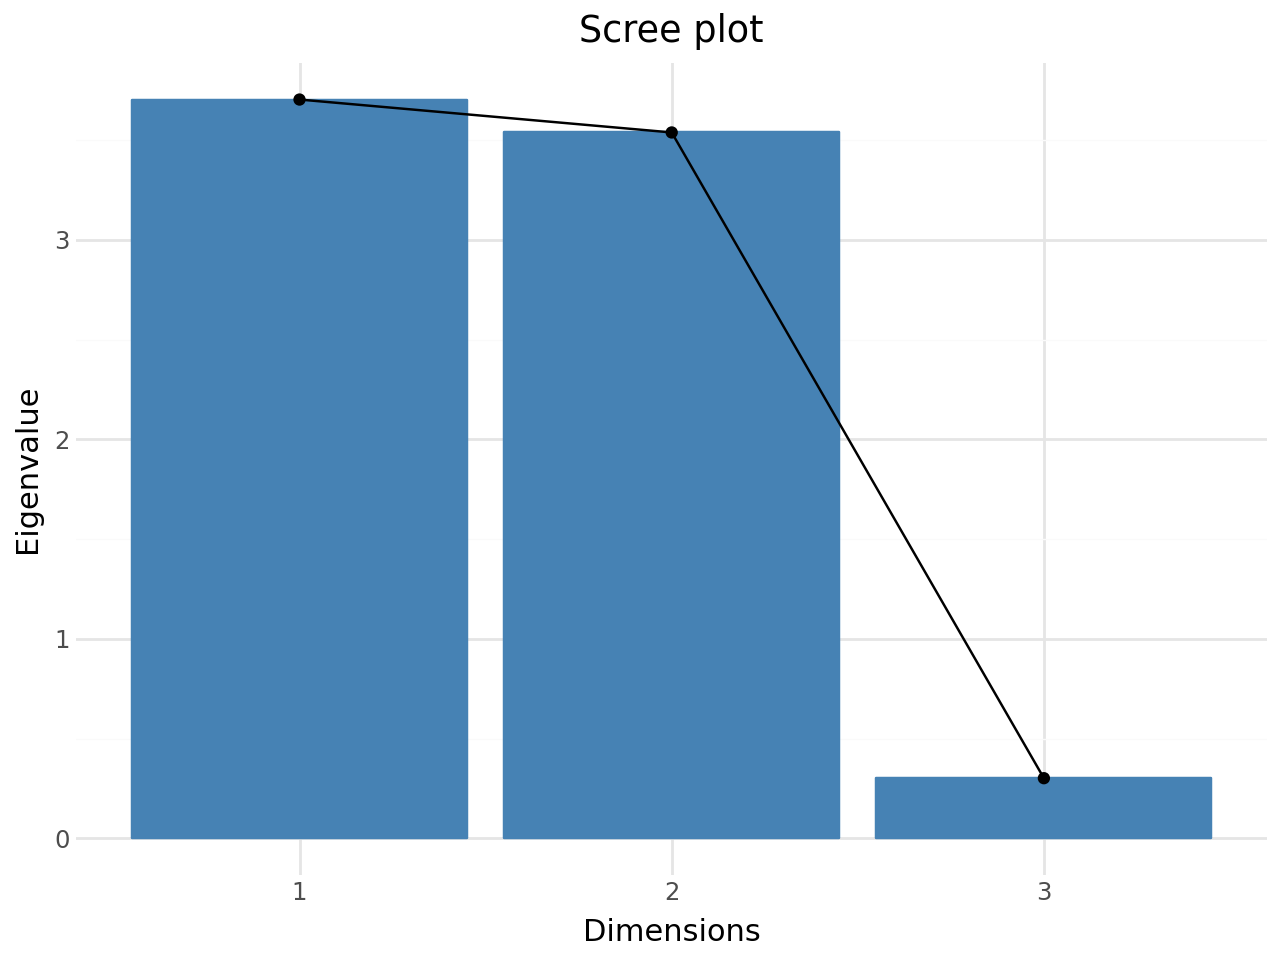

None


In [10]:
# scree plot
from scientisttools import fviz_screeplot
p = fviz_screeplot(clf,choice="eigenvalue")
print(p.show())

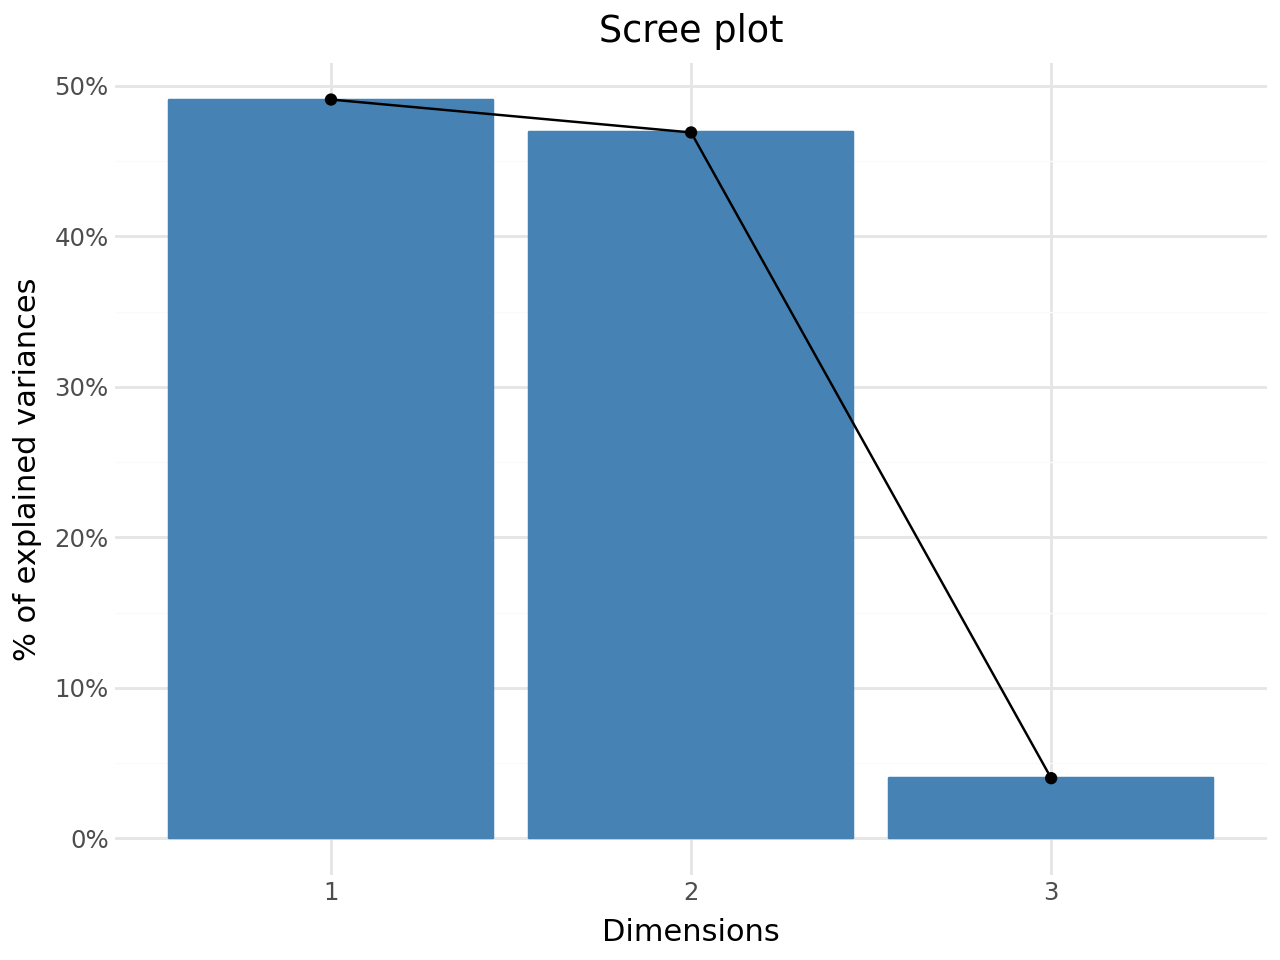

None


In [11]:
# proportion
p = fviz_screeplot(clf,choice="proportion")
print(p.show())

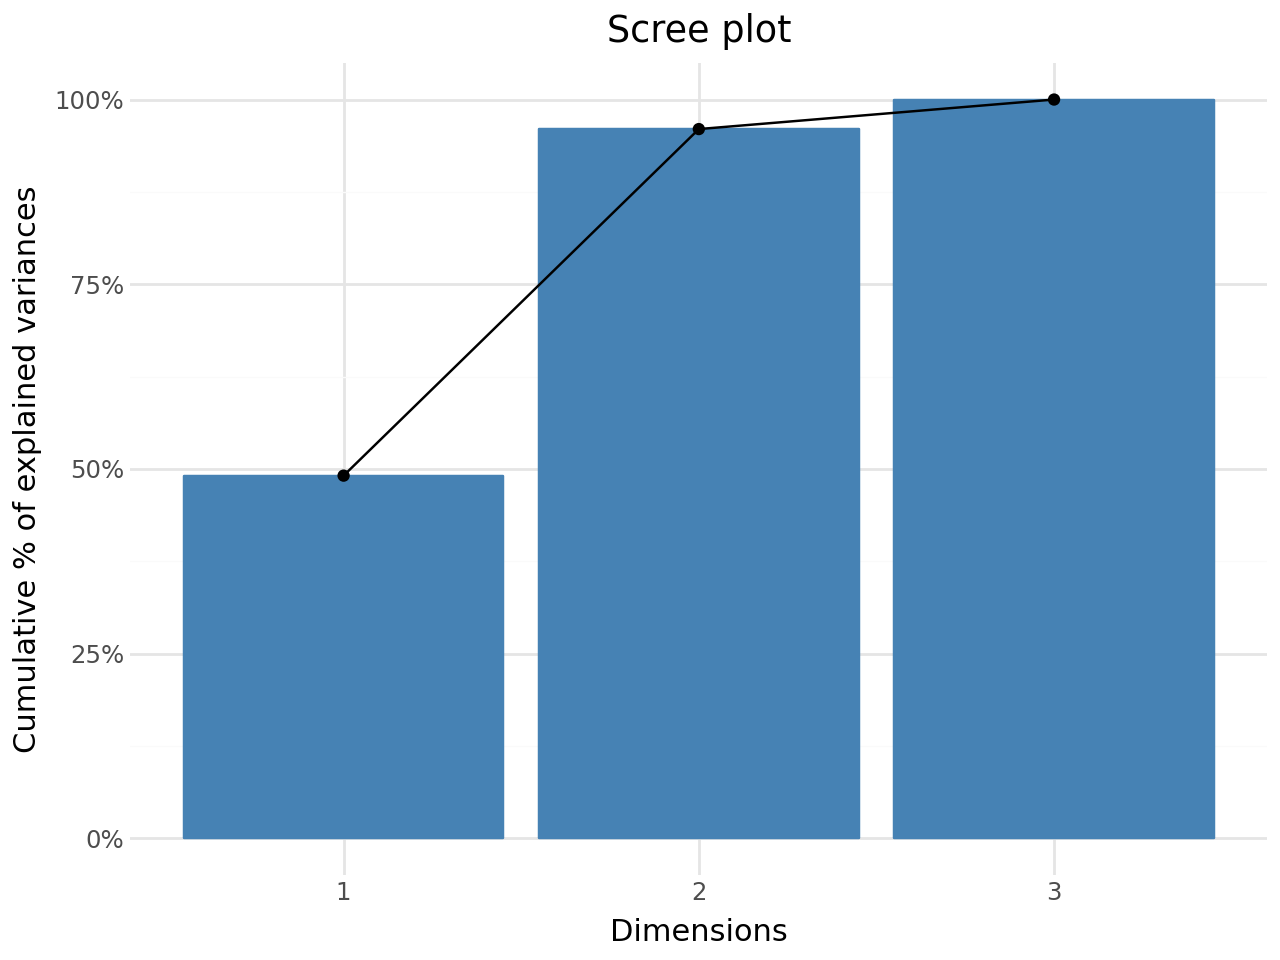

None


In [12]:
# cumulative proportion
p = fviz_screeplot(clf,choice="cumulative")
print(p.show())

## Individuals informations

In [13]:
# individuals informations
from scientisttools import get_pca
ind = get_pca(clf)
ind._fields

('coord', 'cos2', 'contrib', 'infos')

### Individuals coordinates

In [14]:
# individuals coordinates
ind.coord

,Dim1,Dim2,Dim3
0,0.774782,-0.008606,-0.599332
1,1.075483,-1.134220,-0.315285
2,2.532352,0.660453,-0.122311
3,-0.533954,0.267069,-0.664771
4,0.018490,2.148687,-0.642955
5,-1.590846,5.273165,0.295025
6,0.312522,5.830196,-1.735128
7,-1.041387,1.136616,-1.189703
8,-1.401550,-0.043288,-0.516144
9,-2.241797,0.151305,0.637322


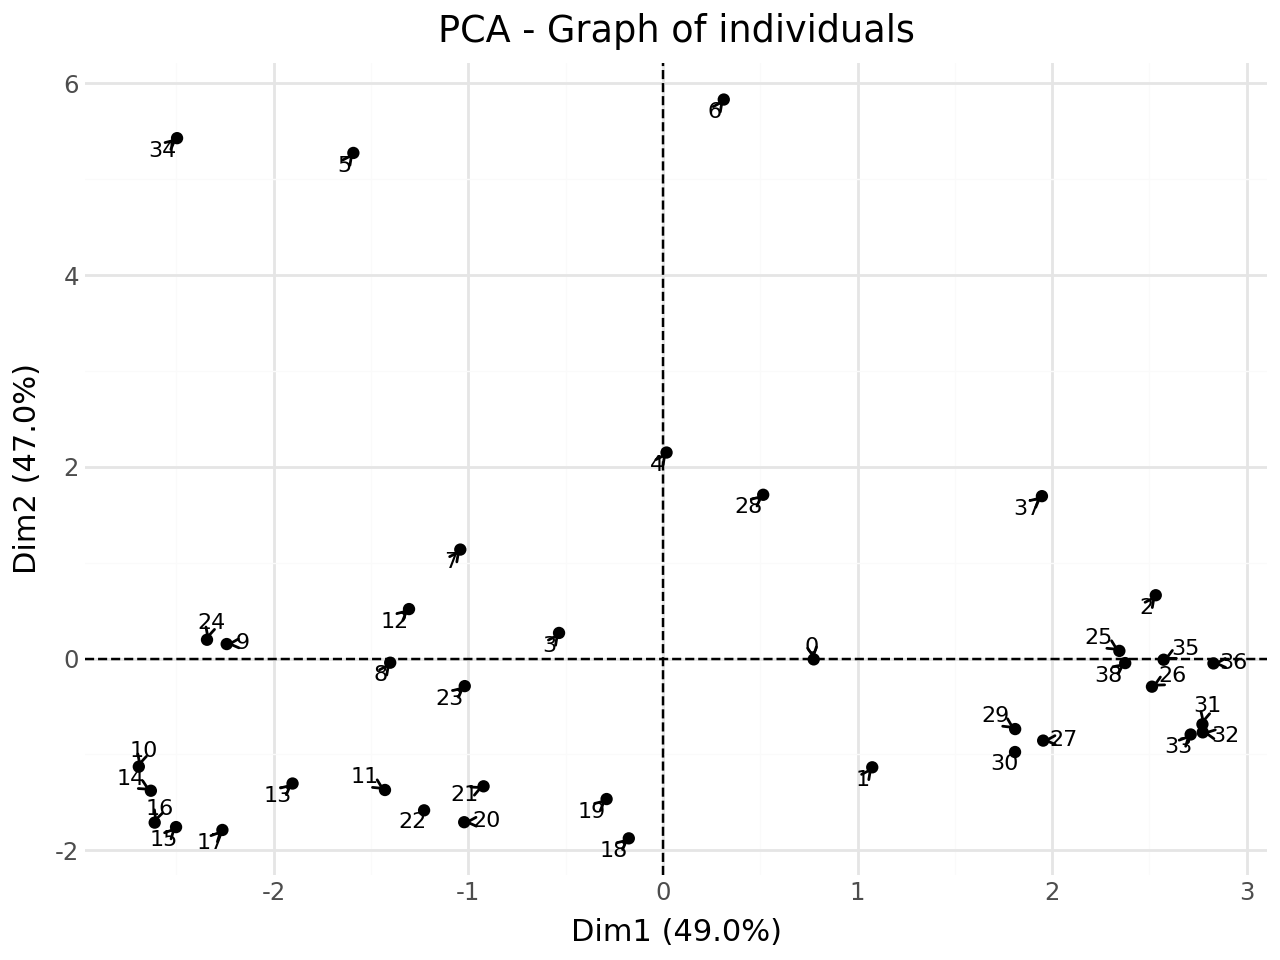

None


In [15]:
# graph of individuals
from scientisttools import fviz_pca
p = fviz_pca(
    obj=clf,
    choice="ind",
    repel=True,
    ind_sup=False,
    quali_sup=False
)
print(p.show())

### Individuals contributions

In [16]:
# individuals contributions
ind.contrib

,Dim1,Dim2,Dim3
0,0.415650,0.000054,3.054576
1,0.800896,0.932309,0.845325
2,4.440349,0.316118,0.127217
3,0.197413,0.051691,3.758035
4,0.000237,3.345894,3.515427
5,1.752367,20.151542,0.740174
6,0.067629,24.633832,25.602315
7,0.750920,0.936254,12.036307
8,1.360148,0.001358,2.265465
9,3.479858,0.016591,3.454096


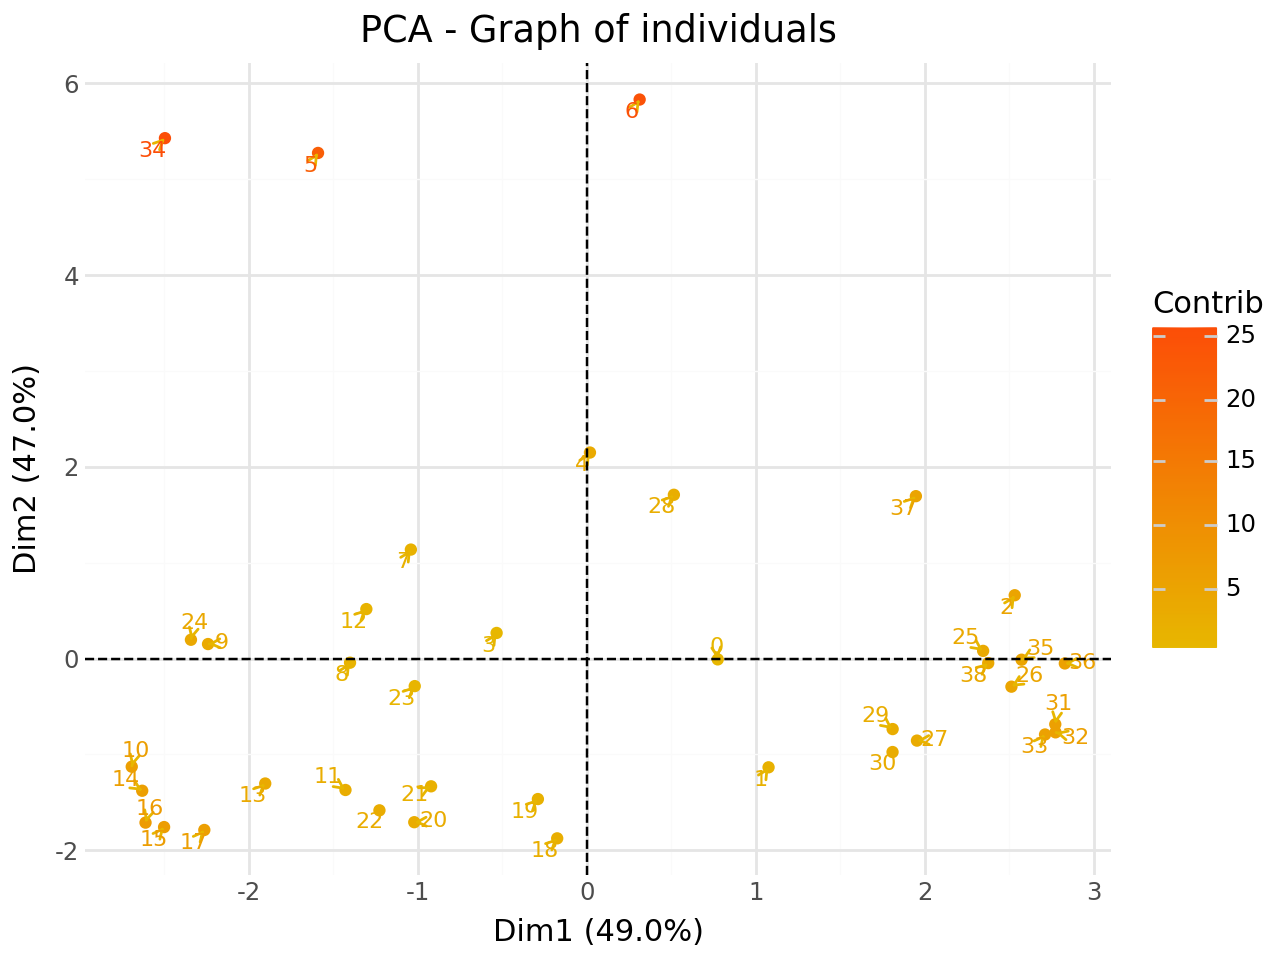

None


In [17]:
# graph of individuals - color by contributions
p = fviz_pca(
    obj=clf,
    choice="ind",
    col_ind="contrib",
    repel=True,
    ind_sup=False,
    quali_sup=False
)
print(p.show())

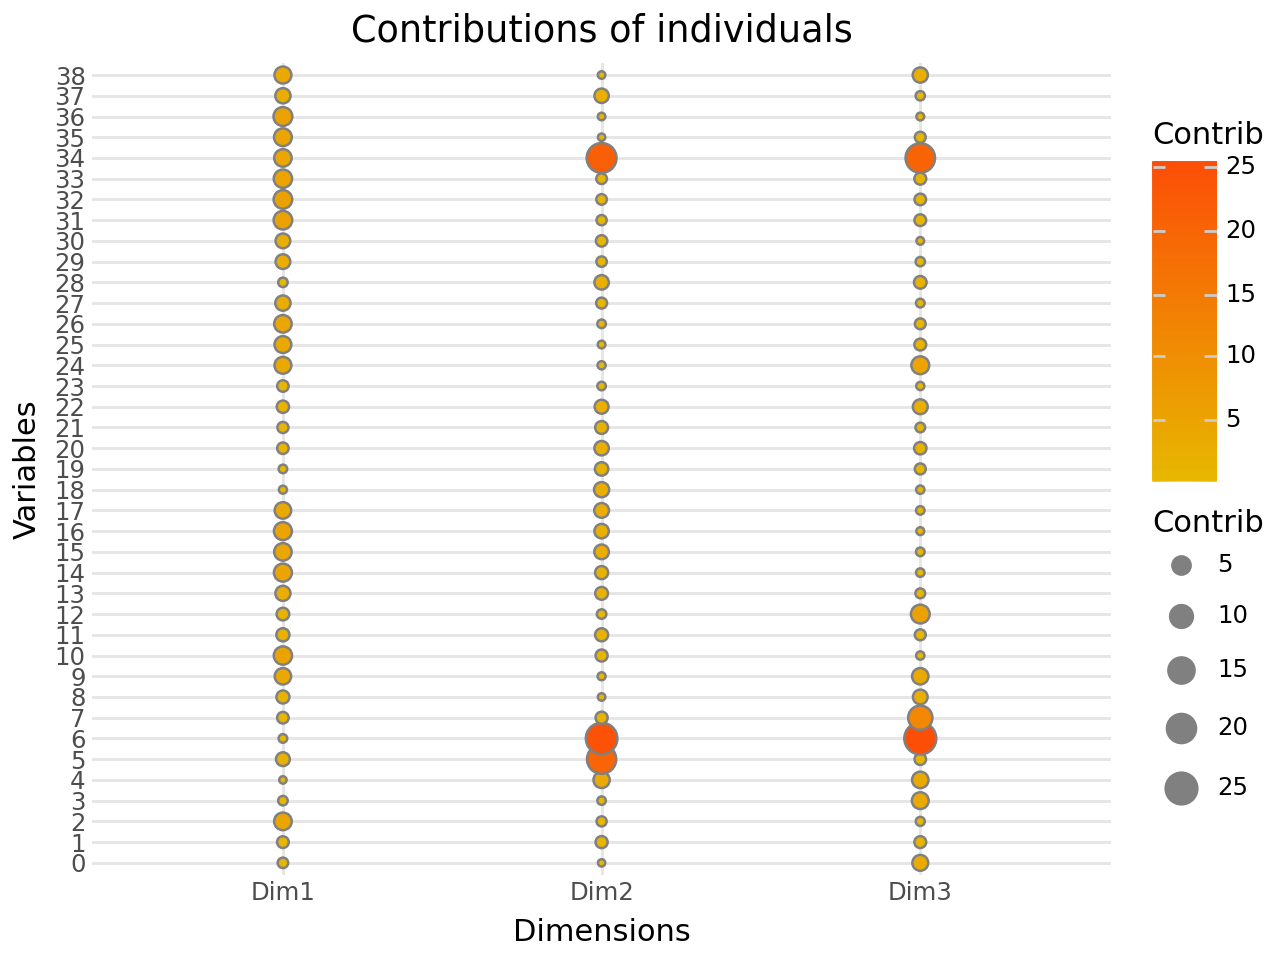

None


In [18]:
# graph 
from scientisttools import fviz_corrplot
p = fviz_corrplot(
    X=ind.contrib,
    legend_title="Contrib",
    title="Contributions of individuals"
)
print(p.show())

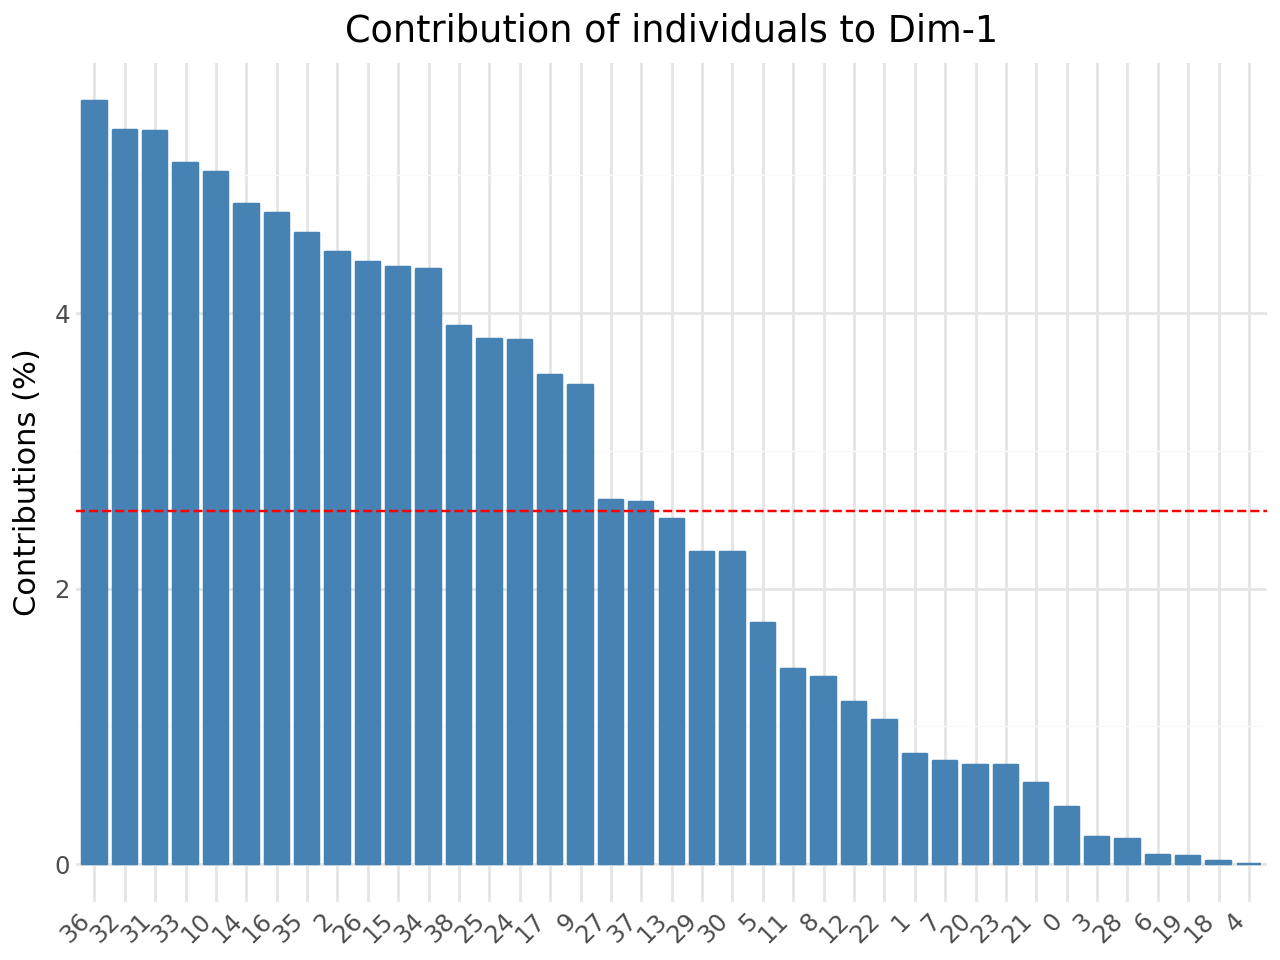

None


In [19]:
# contributions of individuals to axis 1
from scientisttools import fviz_contrib
p = fviz_contrib(
    obj=clf,
    choice="ind"
)
print(p.show())

### Individuals cos2 

In [20]:
# individuals cos2
ind.cos2

,Dim1,Dim2,Dim3
0,0.625586,0.000077,0.374337
1,0.454928,0.505976,0.039097
2,0.934272,0.063549,0.002179
3,0.357119,0.089341,0.553540
4,0.000068,0.917756,0.082176
5,0.083184,0.913955,0.002861
6,0.002633,0.916216,0.081151
7,0.286010,0.340710,0.373279
8,0.879837,0.000839,0.119323
9,0.921339,0.004197,0.074464


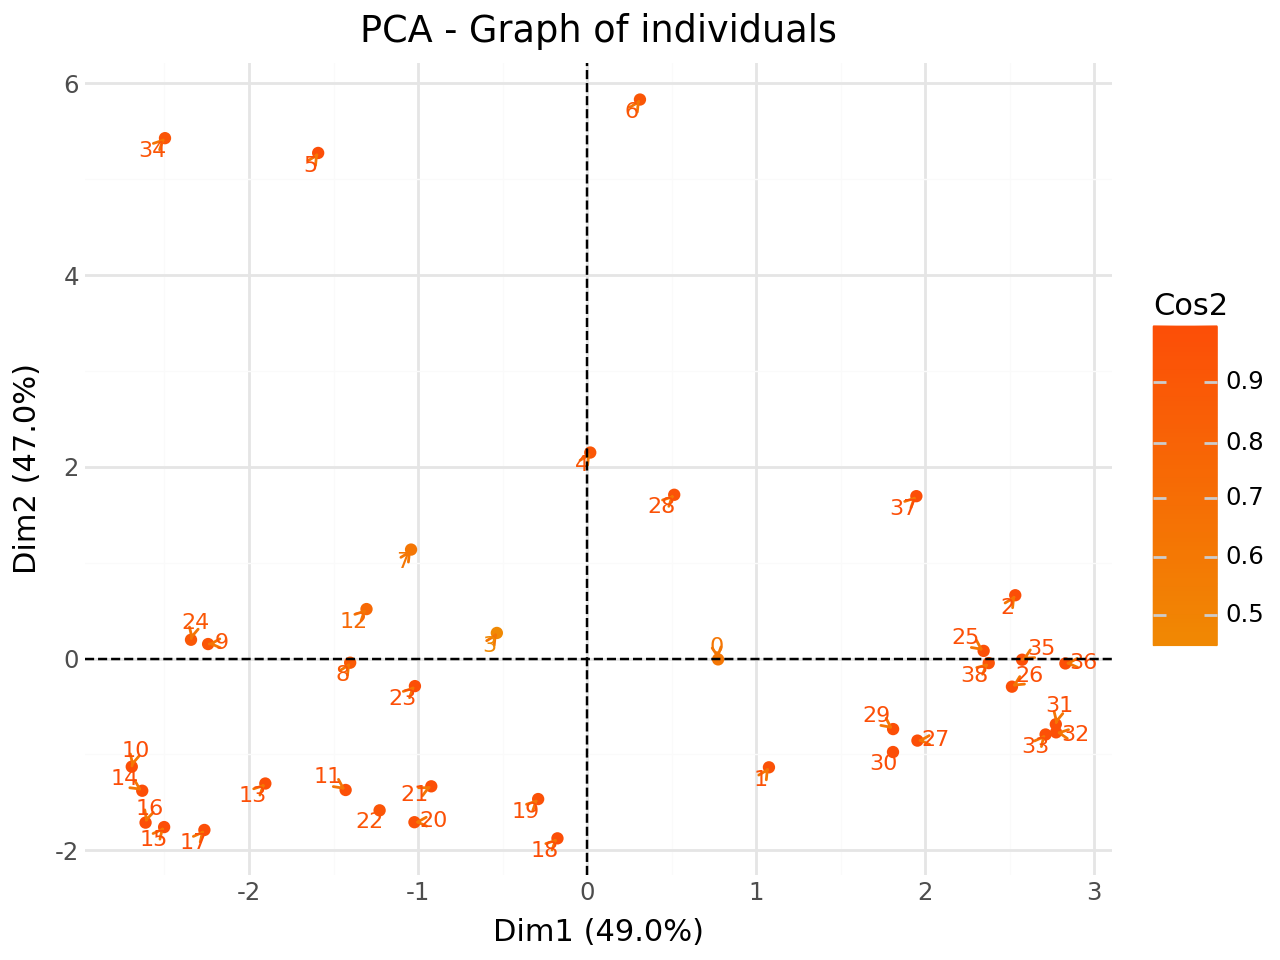

None


In [21]:
# graph of individuals - color by cosinus
p = fviz_pca(
    obj=clf,
    choice="ind",
    col_ind="cos2",
    repel=True,
    ind_sup=False,
    quali_sup=False
)
print(p.show())

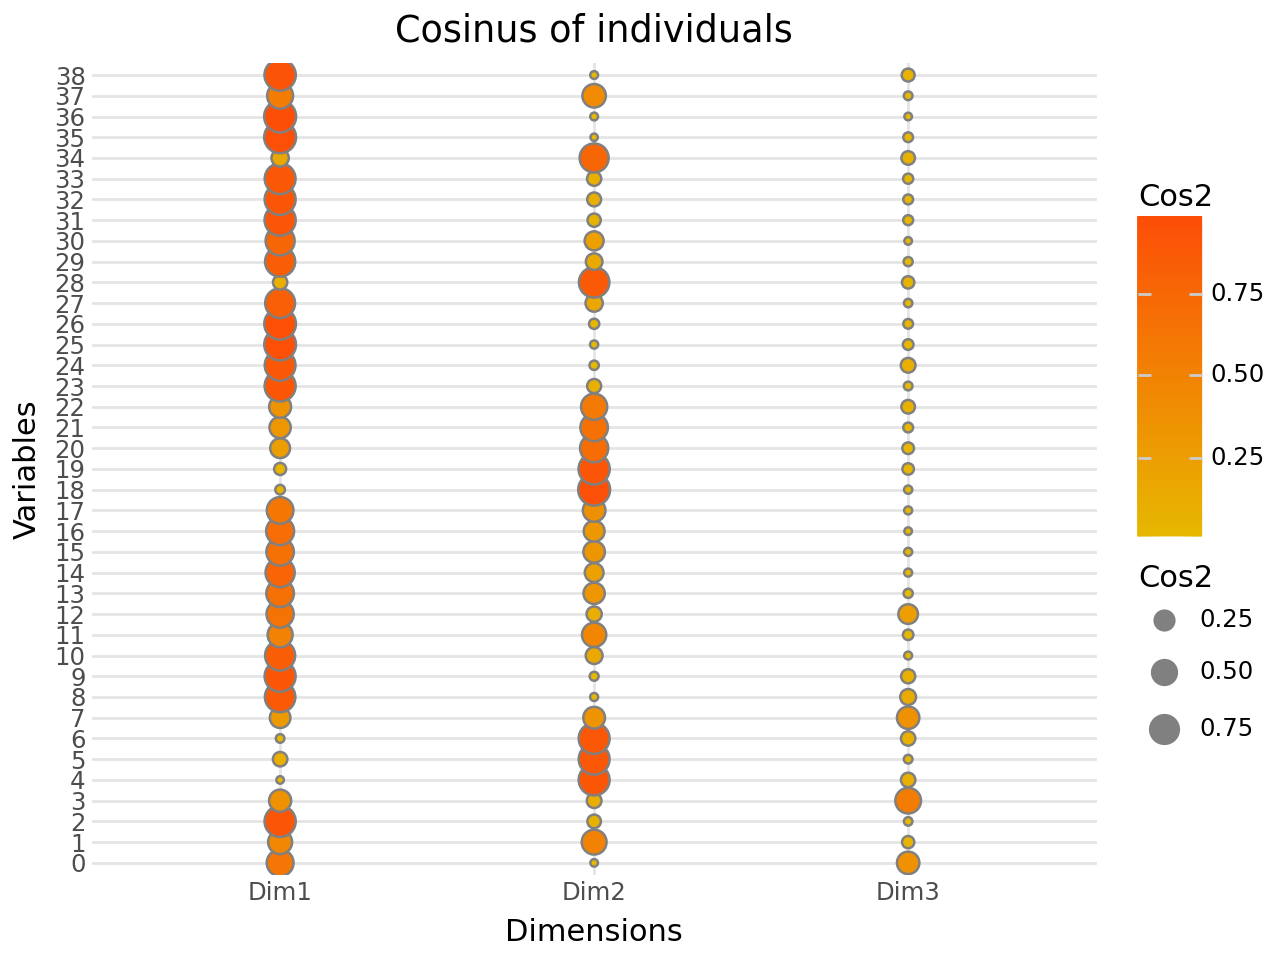

None


In [22]:
# graph of cosinus
p = fviz_corrplot(
    X=ind.cos2,
    legend_title="Cos2",
    title="Cosinus of individuals"
)
print(p.show())

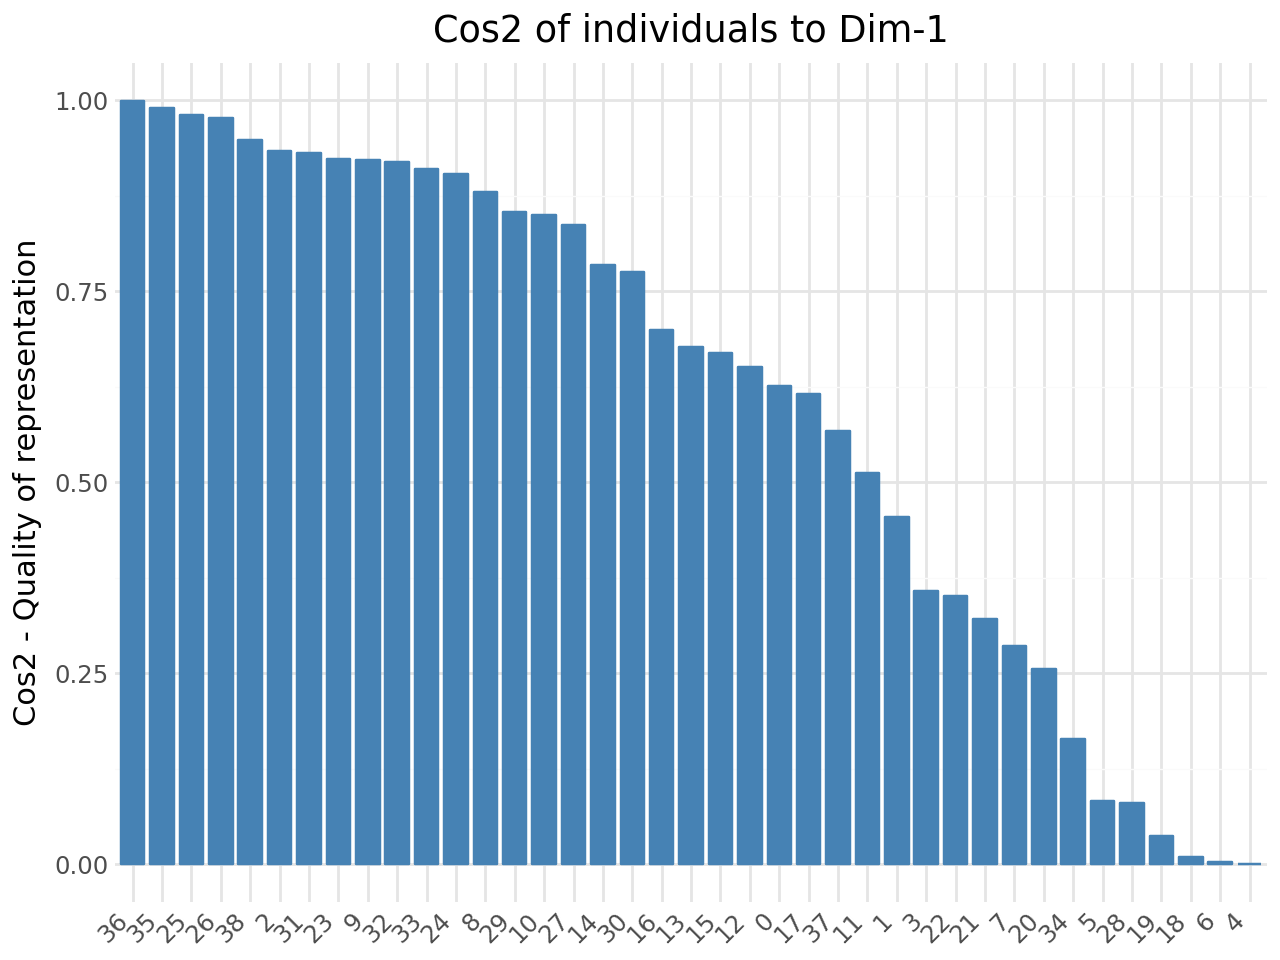

None


In [23]:
# cosinus of individuals to axis 1
from scientisttools import fviz_cos2
p = fviz_cos2(
    obj=clf,
    choice="ind"
)
print(p.show())

### Individuals additionals informations

In [24]:
# individuals additionals informations (weight,squared distance to origin, inertia)
ind.infos

,Weight,Sq. Dist.,Inertia,Inertia (%)
0,0.025641,0.959560,0.024604,0.326196
1,0.025641,2.542523,0.065193,0.864314
2,0.025641,6.863966,0.175999,2.333361
3,0.025641,0.798353,0.020471,0.271395
4,0.025641,5.030591,0.128990,1.710118
5,0.025641,30.424095,0.780105,10.342477
6,0.025641,37.099526,0.951270,12.611748
7,0.025641,3.791778,0.097225,1.288991
8,0.025641,2.232621,0.057247,0.758965
9,0.025641,5.454727,0.139865,1.854300


## Variables informations

In [25]:
# variables informations
var = get_pca(clf,element="var")
var._fields

('coord', 'cos2', 'contrib', 'infos')

### Variables coordinates

In [26]:
# variables coordinates
var.coord

,Dim1,Dim2,Dim3
air.temp,-0.713495,-0.258670,-0.087828
wat.temp,-0.585281,-0.431856,0.012136
conduc,0.591068,0.260191,-0.043506
pH,-0.131916,0.122095,-0.137248
oxygen,-0.573414,0.332797,-0.095957
secchi,0.670102,-0.517329,0.112070
caco3,0.562092,0.468739,0.031276
totca,0.480238,0.545067,0.004085
mg,0.691337,-0.130795,0.144241
so4,0.116815,-0.748026,0.091939


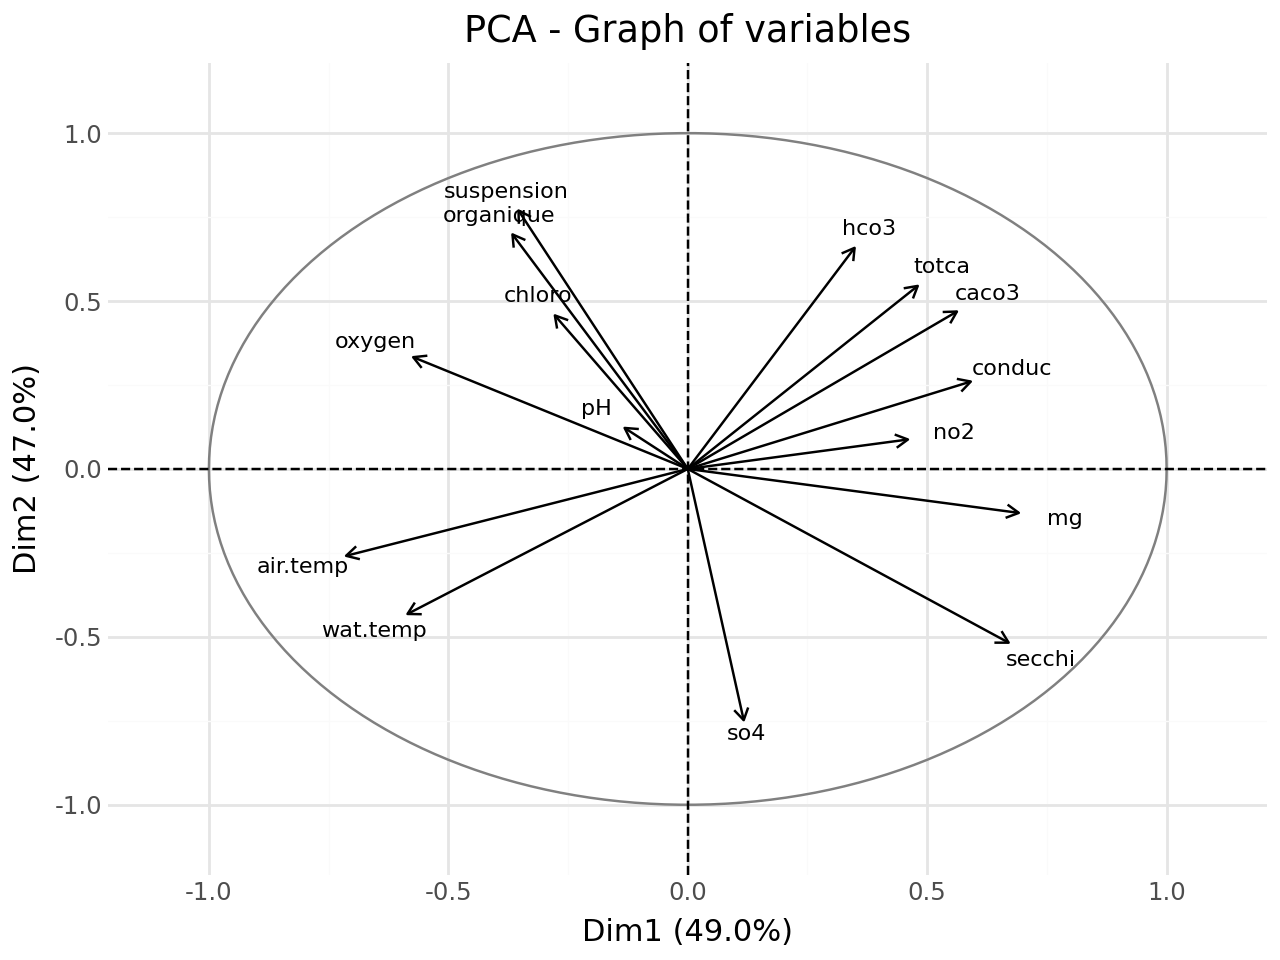

None


In [27]:
# graph of variables - correlation circle
p = fviz_pca(
    obj=clf,
    choice="var",
    repel=True,
    quanti_sup=False
)
print(p.show())

### Variables contributions

In [28]:
# variables contributions
var.contrib

,Dim1,Dim2,Dim3
air.temp,13.747228,1.891133,2.558265
wat.temp,9.250437,5.271181,0.048849
conduc,9.434277,1.913436,0.627741
pH,0.469923,0.421333,6.247299
oxygen,8.879122,3.130322,3.053765
secchi,12.125924,7.564218,4.165443
caco3,8.531939,6.210023,0.324416
totca,6.227970,8.397108,0.005535
mg,12.906624,0.483518,6.900175
so4,0.368495,15.814813,2.803386


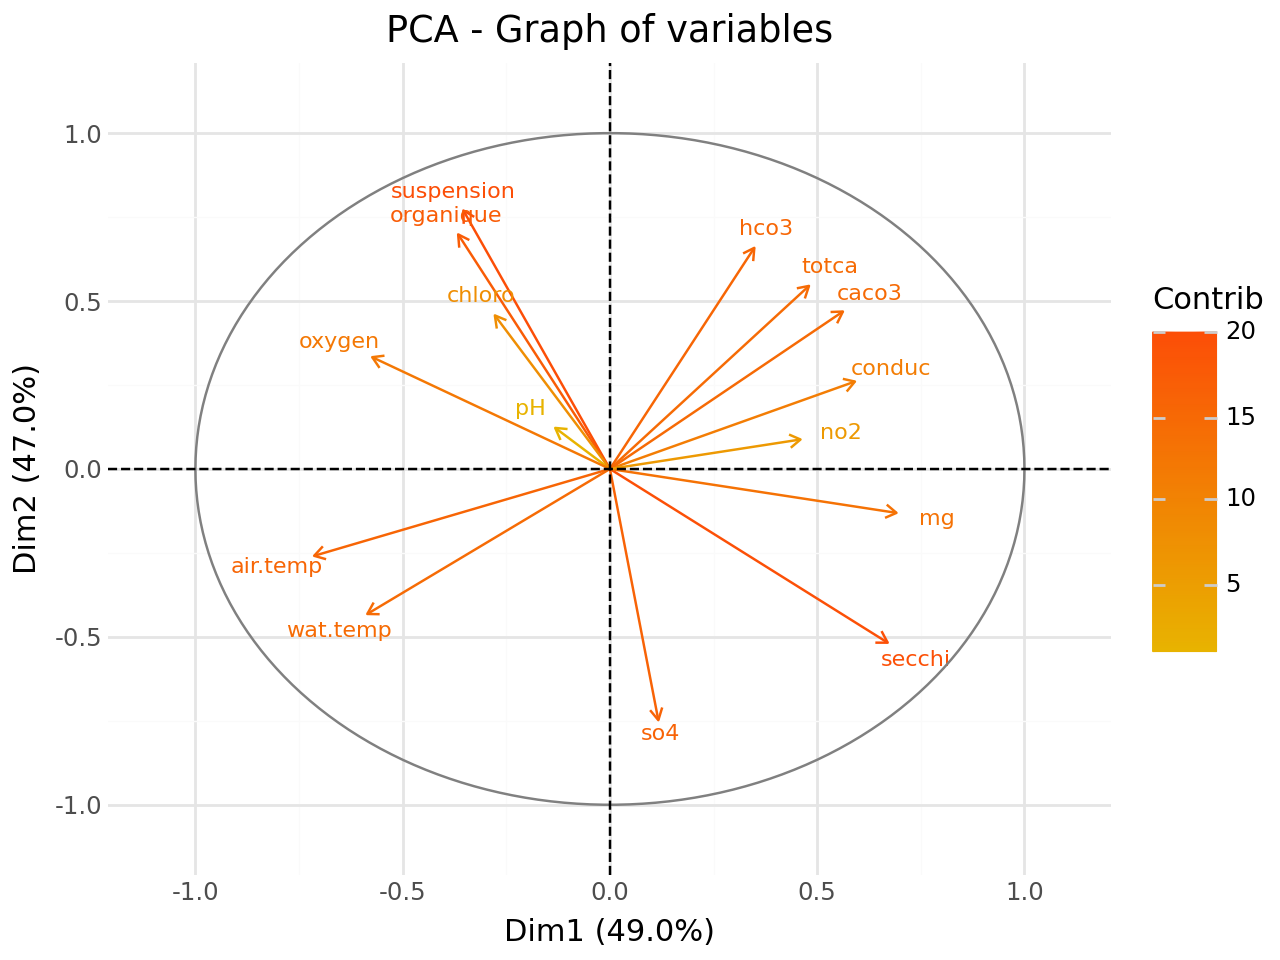

None


In [29]:
# graph of variables - color by contrib
p = fviz_pca(
    obj=clf,
    choice="var",
    col_var = "contrib",
    repel=True,
    quanti_sup=False
)
print(p.show())

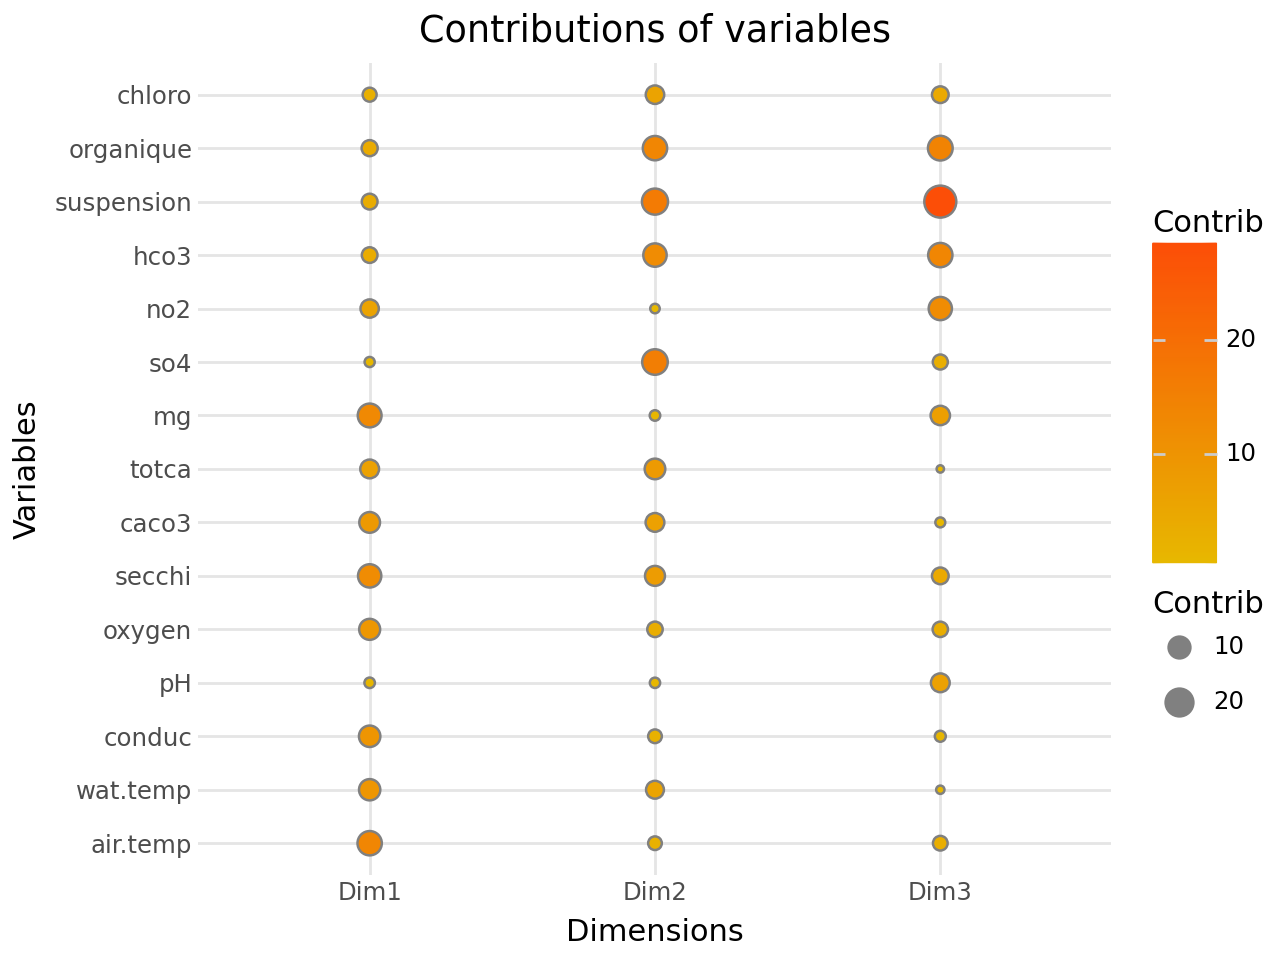

None


In [30]:
# graph of contributions for variables
p = fviz_corrplot(
    X=var.contrib,
    legend_title="Contrib",
    title="Contributions of variables"
)
print(p.show())

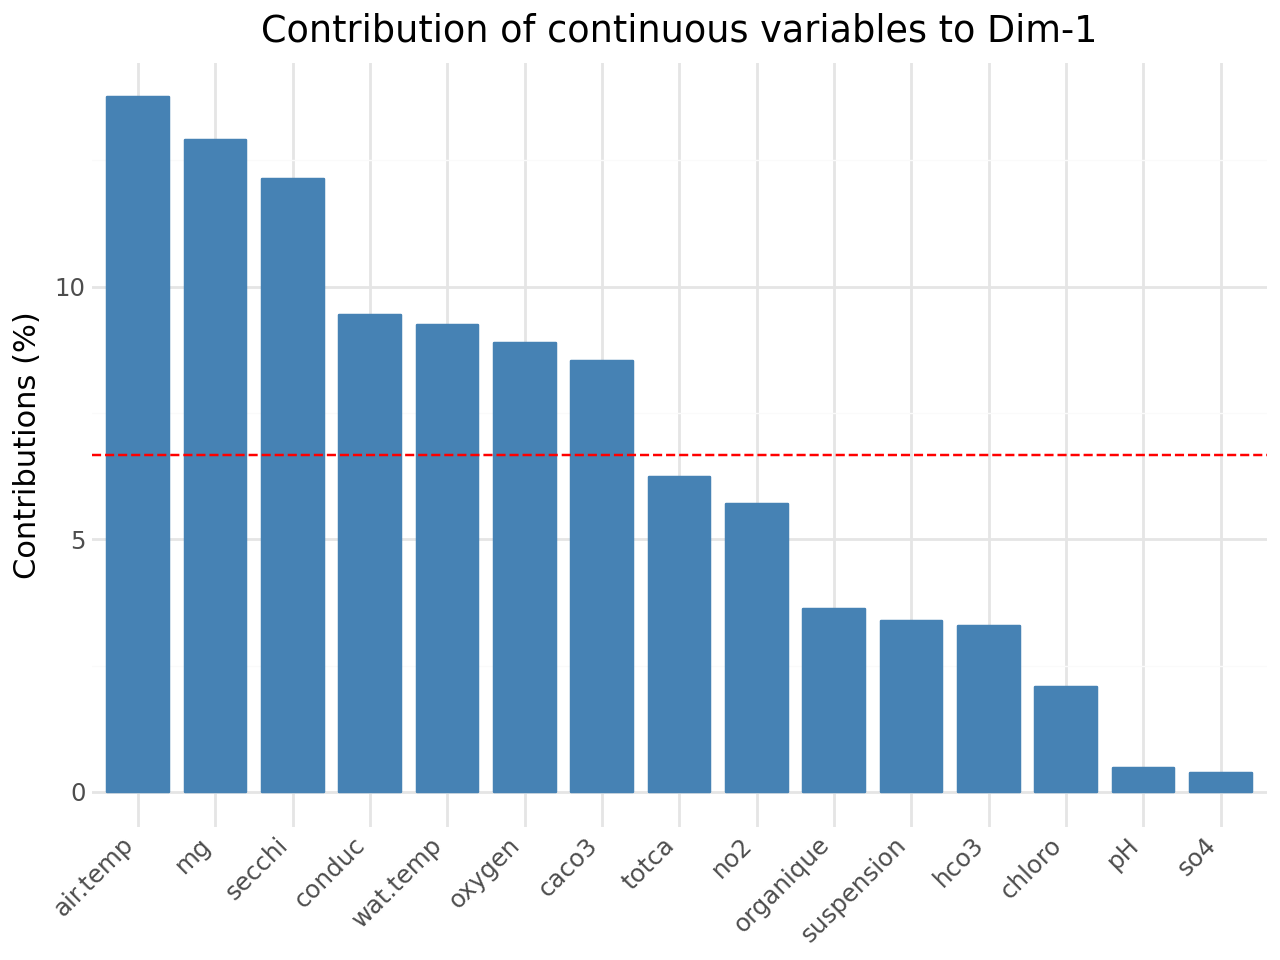

None


In [31]:
# contributions of variables to axis 1
p = fviz_contrib(
    obj=clf,
    choice="quanti_var"
)
print(p.show())

### Variables cos2

In [32]:
# variables cos2
var.cos2

,Dim1,Dim2,Dim3
air.temp,0.872153,0.114631,0.013215
wat.temp,0.647304,0.352417,0.000278
conduc,0.833891,0.161591,0.004518
pH,0.340238,0.291464,0.368299
oxygen,0.732685,0.246797,0.020518
secchi,0.615772,0.367005,0.017223
caco3,0.588748,0.409429,0.001823
totca,0.437009,0.562959,0.000032
mg,0.926505,0.033163,0.040332
so4,0.023461,0.962007,0.014533


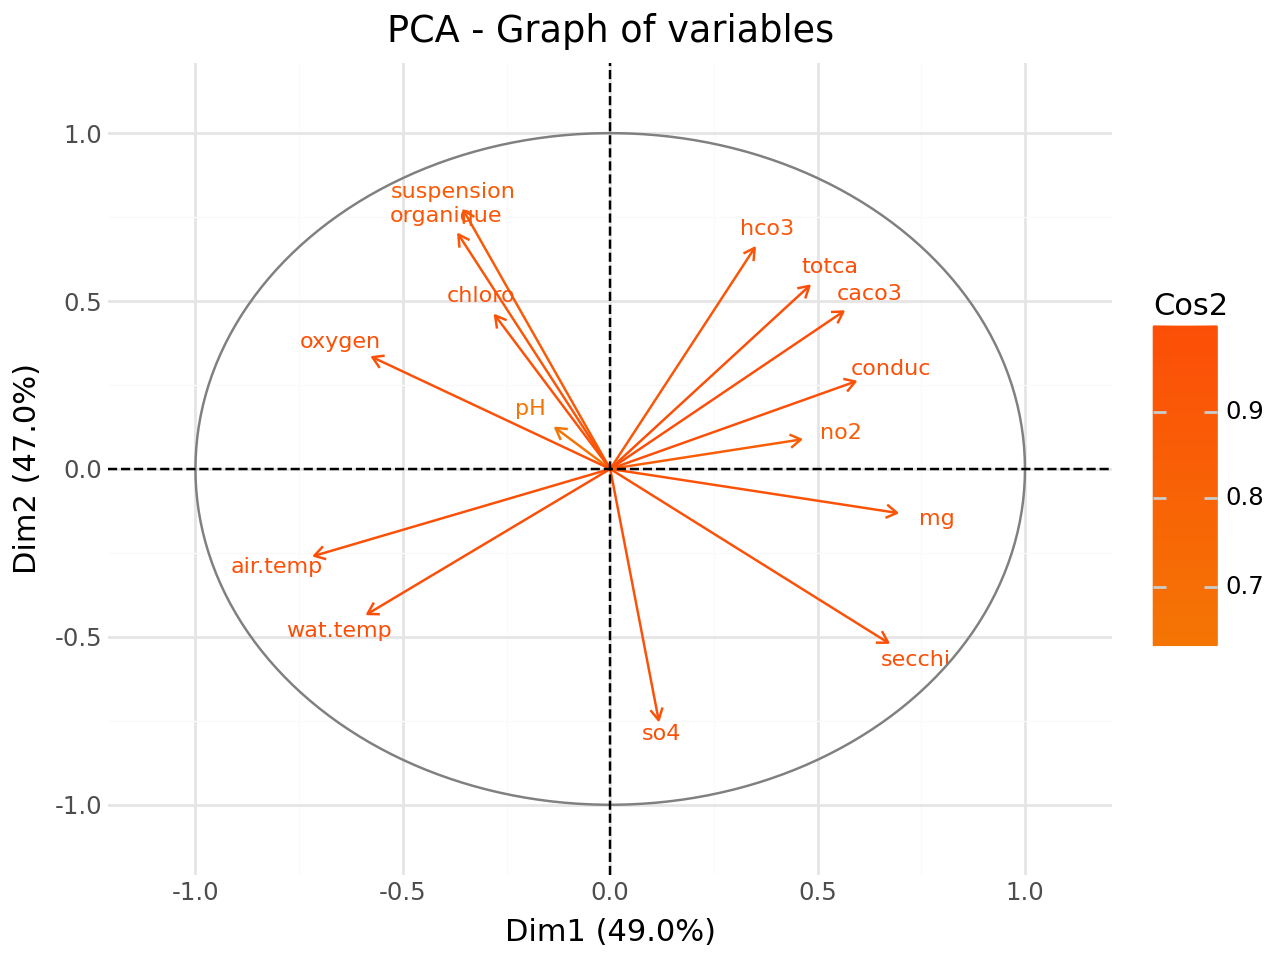

None


In [33]:
# graph of variables - color by cosinus
p = fviz_pca(
    obj=clf,
    choice="var",
    col_var = "cos2",
    repel=True,
    quanti_sup=False
)
print(p.show())

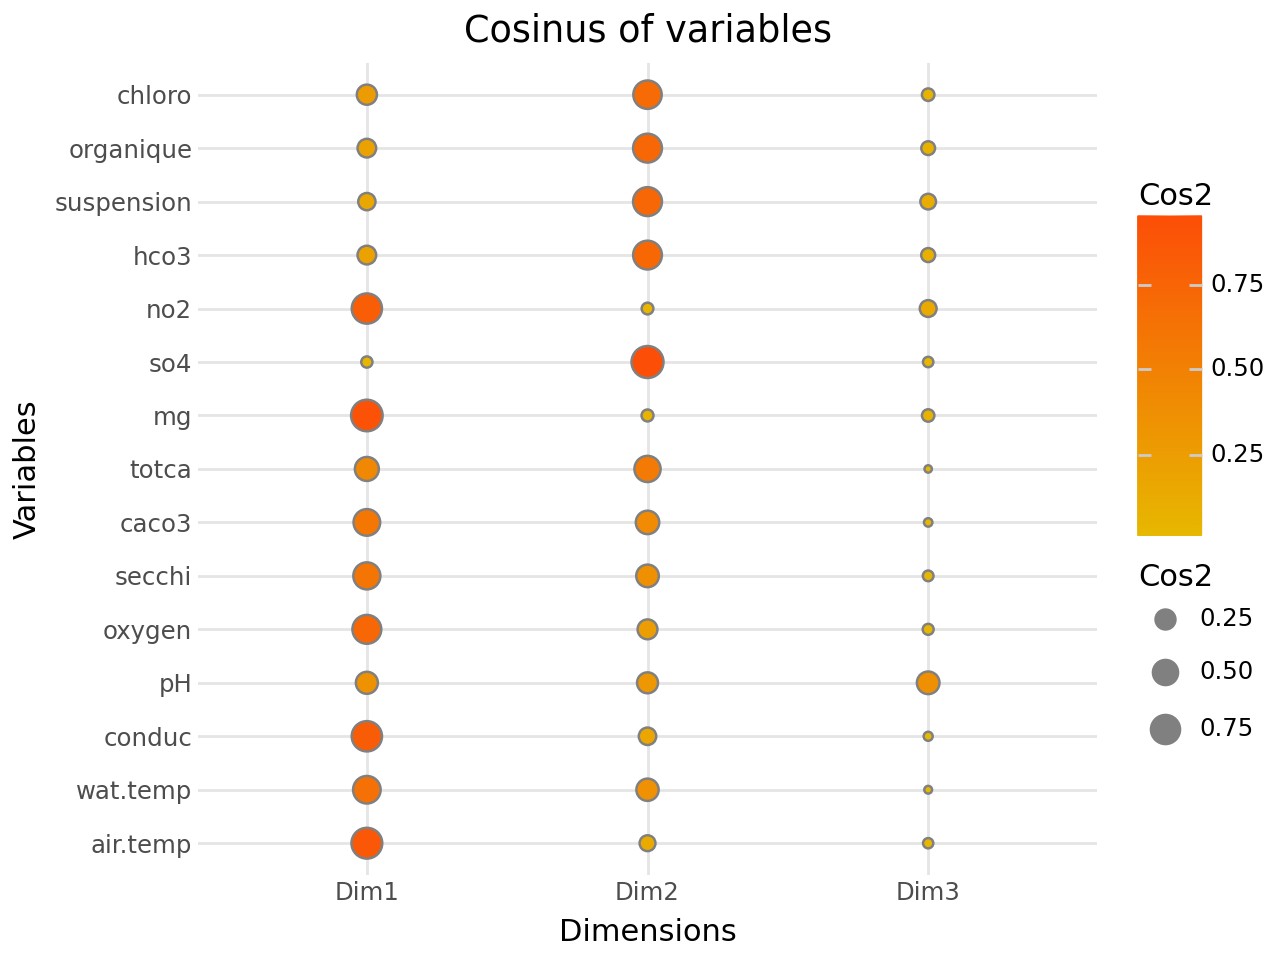

None


In [34]:
# graph of cosinus for variables
p = fviz_corrplot(
    X=var.cos2,
    legend_title="Cos2",
    title="Cosinus of variables"
)
print(p.show())

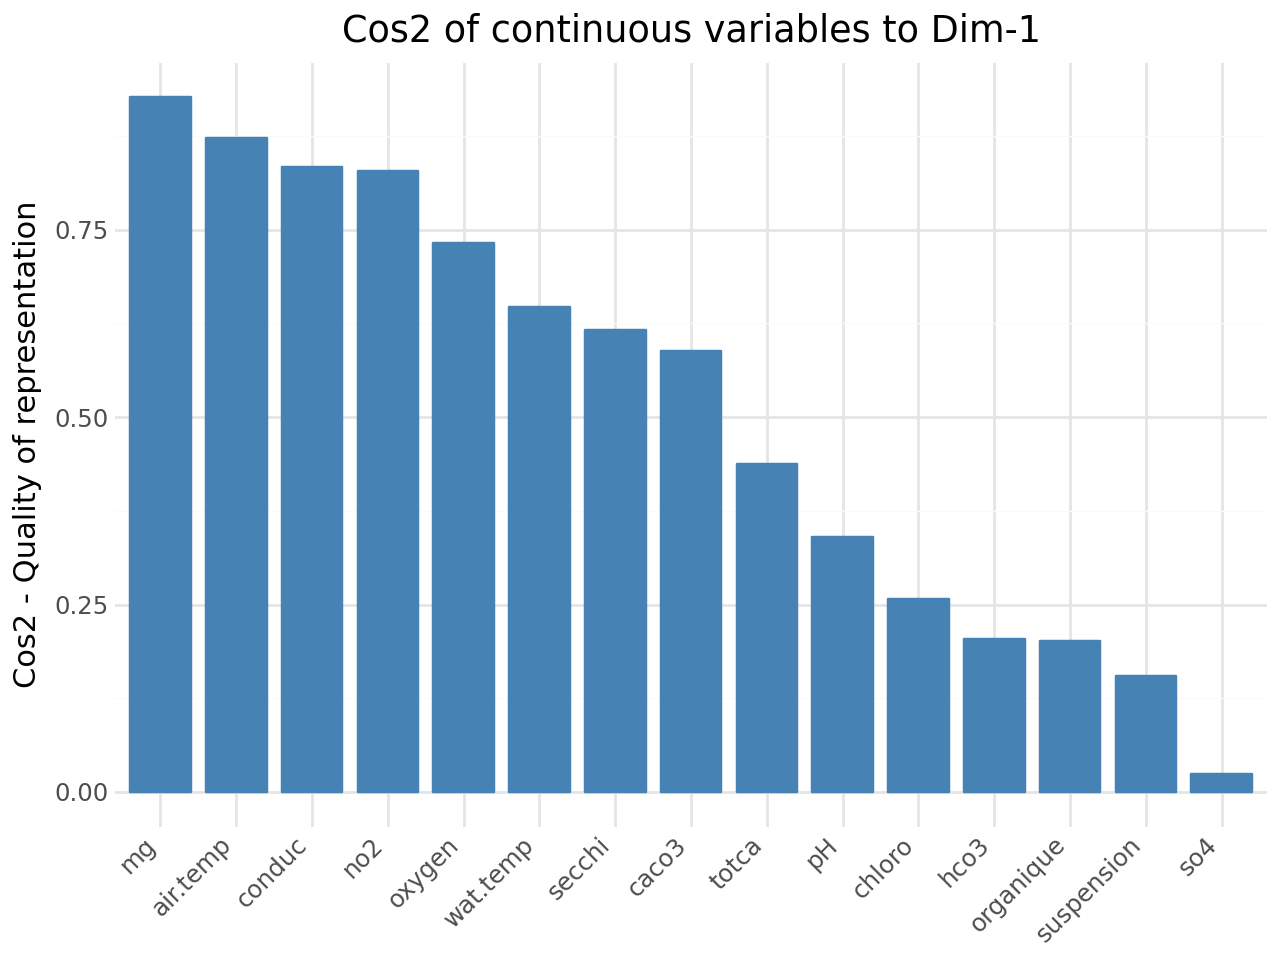

None


In [35]:
# cosinus of variables to axis 1
p = fviz_cos2(
    obj=clf,
    choice="quanti_var"
)
print(p.show())

### Variables addtionals informations

In [36]:
# variables additionals informations
var.infos

,Weight,Sq. Dist.,Inertia,Inertia (%)
air.temp,1.0,0.583699,0.583699,7.738562
wat.temp,1.0,0.529201,0.529201,7.016036
conduc,1.0,0.418954,0.418954,5.554404
pH,1.0,0.051146,0.051146,0.678083
oxygen,1.0,0.448765,0.448765,5.949640
secchi,1.0,0.729225,0.729225,9.667925
caco3,1.0,0.536642,0.536642,7.114691
totca,1.0,0.527743,0.527743,6.996713
mg,1.0,0.515859,0.515859,6.839160
so4,1.0,0.581642,0.581642,7.711295


## Biplot

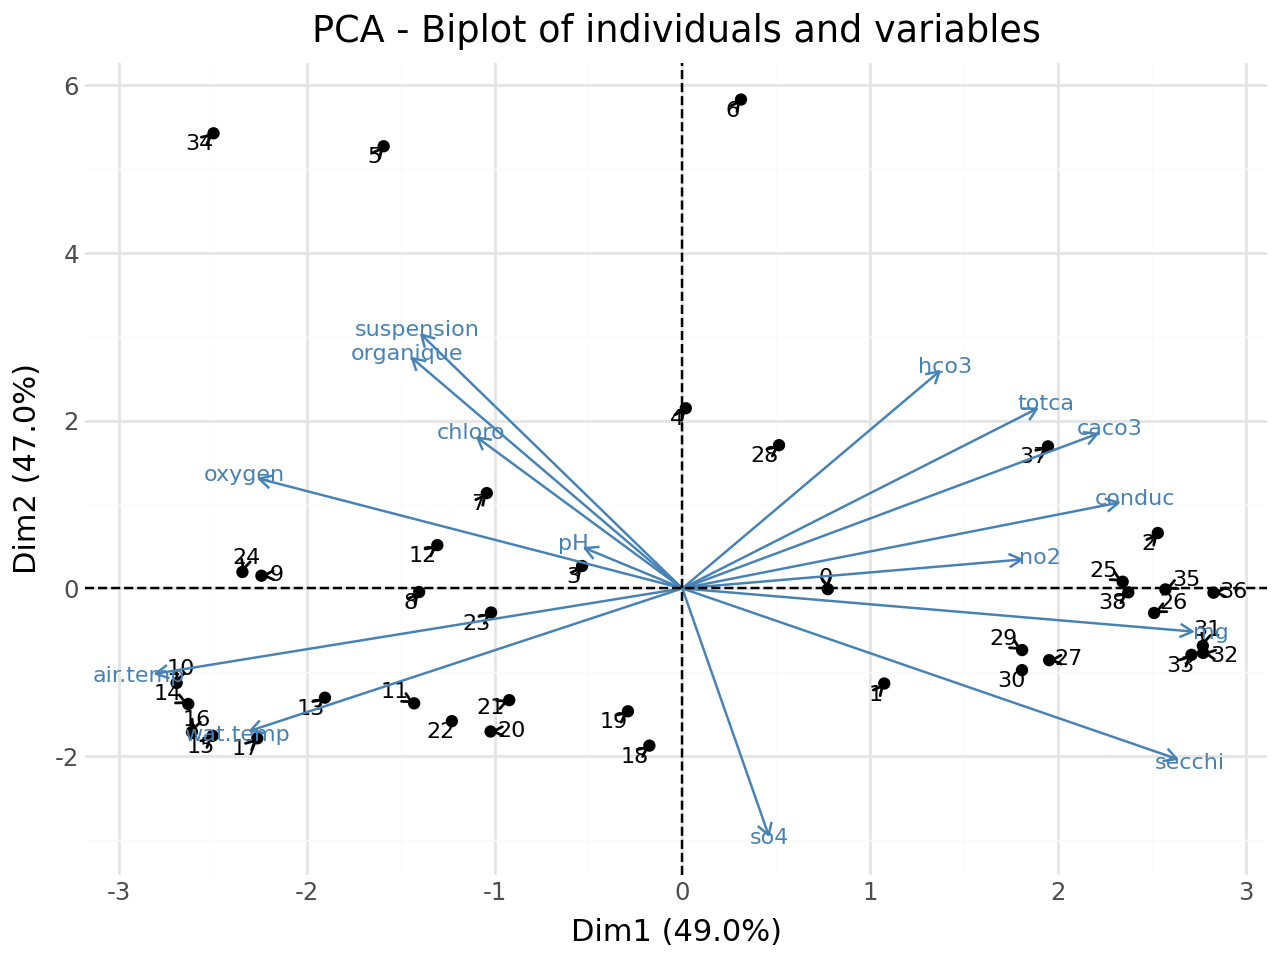

None


In [37]:
# biplot of individuals and variables
p = fviz_pca(
    obj=clf,
    choice ="biplot",
    repel_ind = True,
    repel_var = True,
    ind_sup=False,
    quanti_sup = False,
    quali_sup=False
)
print(p.show())

## Summary

In [38]:
# summary
from scientisttools import summary
summary(clf)

                     Principal Component Analysis - Results                     

Importance of components:
      Eigenvalue  Difference  Proportion (%)  Cumulative (%)
Dim1      3.7031      0.1650         49.0951         49.0951
Dim2      3.5381      3.2366         46.9074         96.0025
Dim3      0.3015         NaN          3.9975        100.0000

Individuals (the 10 first):
     Dim1    cos2     ctr    Dim2    cos2      ctr    Dim3    cos2      ctr
0  0.7748  0.6256  0.4157 -0.0086  0.0001   0.0001 -0.5993  0.3743   3.0546
1  1.0755  0.4549  0.8009 -1.1342  0.5060   0.9323 -0.3153  0.0391   0.8453
2  2.5324  0.9343  4.4403  0.6605  0.0635   0.3161 -0.1223  0.0022   0.1272
3 -0.5340  0.3571  0.1974  0.2671  0.0893   0.0517 -0.6648  0.5535   3.7580
4  0.0185  0.0001  0.0002  2.1487  0.9178   3.3459 -0.6430  0.0822   3.5154
5 -1.5908  0.0832  1.7524  5.2732  0.9140  20.1515  0.2950  0.0029   0.7402
6  0.3125  0.0026  0.0676  5.8302  0.9162  24.6338 -1.7351  0.0812  25.6023
7 -1.0414  

In [39]:
# formatting text to markdown
summary(clf,to_markdown=True)

                     Principal Component Analysis - Results                     

Importance of components:
        Eigenvalue    Difference    Proportion (%)    Cumulative (%)
----  ------------  ------------  ----------------  ----------------
Dim1        3.7031        0.165            49.0951           49.0951
Dim2        3.5381        3.2366           46.9074           96.0025
Dim3        0.3015      nan                 3.9975          100

Individuals (the 10 first):
       Dim1    cos2     ctr     Dim2    cos2      ctr     Dim3    cos2      ctr
--  -------  ------  ------  -------  ------  -------  -------  ------  -------
 0   0.7748  0.6256  0.4157  -0.0086  0.0001   0.0001  -0.5993  0.3743   3.0546
 1   1.0755  0.4549  0.8009  -1.1342  0.506    0.9323  -0.3153  0.0391   0.8453
 2   2.5324  0.9343  4.4403   0.6605  0.0635   0.3161  -0.1223  0.0022   0.1272
 3  -0.534   0.3571  0.1974   0.2671  0.0893   0.0517  -0.6648  0.5535   3.758
 4   0.0185  0.0001  0.0002   2.1487  0.9178